# Tutorial Notebook 2: Step-by-Step Regression with Vienna Airbnb Data

This version is **standalone**: it works directly from the raw `listings_Vienna.csv` file, so students do not need an intermediate handoff table.

The notebook is designed for teaching:
- one regression model first (**Linear Regression**),
- then multiple models (**Linear Regression**, **Lasso Regression**, **Decision Tree Regressor**),
- with preprocessing explained step by step,
- and simple hyperparameter experiments at the end.

Ridge Regression and Random Forest are intentionally left for the grading assignment.

In [4]:
# ============================================================
# 0. Imports and settings
# ============================================================
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (10, 6)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

## 1. Resolve the raw dataset path

We try to load the raw Vienna Airbnb listings file.  
This keeps the notebook self-contained and reproducible.

In [5]:
# ============================================================
# 1. Resolve the raw data file path
# ============================================================
candidate_paths = [
    Path("listings_Vienna.csv"),
    Path("data/listings_Vienna.csv"),
]

data_path = None
for p in candidate_paths:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("Could not find listings_Vienna.csv")

print("Using file:", data_path)

Using file: data\listings_Vienna.csv


## 2. Load the raw dataset

We first inspect the size and the most relevant columns.

In [6]:
# ============================================================
# 2. Load the raw Vienna Airbnb table
# ============================================================
df = pd.read_csv(data_path, low_memory=False)

print("Shape:", df.shape)
print("\nFirst 10 columns:")
print(df.columns[:10].tolist())
print("\nImportant modeling columns available:")
important_cols = [
    "price", "room_type", "property_type", "latitude", "longitude",
    "accommodates", "bathrooms", "bathrooms_text", "bedrooms", "beds",
    "minimum_nights", "maximum_nights", "availability_365",
    "number_of_reviews", "reviews_per_month", "host_response_time",
    "host_response_rate", "host_acceptance_rate", "host_is_superhost",
    "host_identity_verified", "instant_bookable", "amenities",
    "neighbourhood_cleansed", "review_scores_rating"
]
print([c for c in important_cols if c in df.columns])

Shape: (14123, 79)

First 10 columns:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id']

Important modeling columns available:
['price', 'room_type', 'property_type', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews', 'reviews_per_month', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_identity_verified', 'instant_bookable', 'amenities', 'neighbourhood_cleansed', 'review_scores_rating']


## 3. Create the regression target: `price_num`

Airbnb prices are stored as text.  
We convert them into a numeric variable called `price_num`.

In [7]:
# ============================================================
# 3. Parse price into a numeric target
# ============================================================
def parse_price(value):
    if pd.isna(value):
        return np.nan

    s = str(value).strip()

    # Keep only digits, decimal points, and minus signs
    s = re.sub(r"[^0-9.\-]", "", s)

    if s == "":
        return np.nan

    try:
        return float(s)
    except ValueError:
        return np.nan

df["price_num"] = df["price"].map(parse_price)

print("Missing price_num ratio:", round(df["price_num"].isna().mean(), 4))
print("\nPrice summary before filtering:")
print(df["price_num"].describe())

Missing price_num ratio: 0.2703

Price summary before filtering:
count    10306.000000
mean       156.727634
std        533.463760
min         13.000000
25%         66.000000
50%         93.000000
75%        140.000000
max      10000.000000
Name: price_num, dtype: float64


## 4. Engineer a few useful features from the raw table

The raw file contains some columns in text form.  
We convert them into cleaner modeling features.

Examples:
- percentages such as `"95%"` become numbers like `95`,
- true/false fields become `1/0`,
- bathroom text is converted into a numeric count,
- amenities are converted into a simple count.

In [8]:
# ============================================================
# 4. Feature engineering from raw columns
# ============================================================
def parse_bathrooms(value):
    if pd.isna(value):
        return np.nan

    s = str(value)
    match = re.search(r"(\d+(\.\d+)?)", s)

    if match:
        return float(match.group(1))
    return np.nan

def parse_percent(value):
    if pd.isna(value):
        return np.nan

    s = str(value).strip().replace("%", "")

    try:
        return float(s)
    except ValueError:
        return np.nan

def parse_boolean(value):
    if pd.isna(value):
        return np.nan

    s = str(value).strip().lower()

    if s in ["t", "true", "yes", "1"]:
        return 1
    if s in ["f", "false", "no", "0"]:
        return 0

    return np.nan

def count_amenities(value):
    if pd.isna(value):
        return 0

    s = str(value)

    # Airbnb stores amenities as a long text list.
    # Counting quoted items gives a simple approximate amenity count.
    return len(re.findall(r'"[^"]+"', s))

# Bathrooms
df["bathrooms_num"] = pd.to_numeric(df.get("bathrooms"), errors="coerce")
bath_mask = df["bathrooms_num"].isna()
df.loc[bath_mask, "bathrooms_num"] = df.loc[bath_mask, "bathrooms_text"].map(parse_bathrooms)

# Percent-like host fields
df["host_response_rate_num"] = df["host_response_rate"].map(parse_percent)
df["host_acceptance_rate_num"] = df["host_acceptance_rate"].map(parse_percent)

# Boolean-like fields
df["host_is_superhost_num"] = df["host_is_superhost"].map(parse_boolean)
df["host_identity_verified_num"] = df["host_identity_verified"].map(parse_boolean)
df["instant_bookable_num"] = df["instant_bookable"].map(parse_boolean)

# Date-like fields converted to number of days
reference_date = pd.Timestamp("2025-01-01")
df["host_tenure_days"] = (reference_date - pd.to_datetime(df["host_since"], errors="coerce")).dt.days
df["days_since_last_review"] = (reference_date - pd.to_datetime(df["last_review"], errors="coerce")).dt.days

# Amenity count
df["amenity_count"] = df["amenities"].map(count_amenities)

# A single neighborhood column for modeling
df["neighbourhood_joined"] = df["neighbourhood_cleansed"].fillna(df["neighbourhood"])

engineered_cols = [
    "bathrooms_num",
    "host_response_rate_num",
    "host_acceptance_rate_num",
    "host_is_superhost_num",
    "host_identity_verified_num",
    "instant_bookable_num",
    "host_tenure_days",
    "days_since_last_review",
    "amenity_count",
    "neighbourhood_joined",
]
print(df[engineered_cols].head())

   bathrooms_num  host_response_rate_num  host_acceptance_rate_num  \
0            1.0                   100.0                      95.0   
1            1.0                   100.0                     100.0   
2            1.0                   100.0                      95.0   
3            1.0                   100.0                      95.0   
4            1.0                     NaN                       NaN   

   host_is_superhost_num  host_identity_verified_num  instant_bookable_num  \
0                    NaN                         1.0                     0   
1                    1.0                         1.0                     0   
2                    NaN                         1.0                     0   
3                    NaN                         1.0                     0   
4                    0.0                         1.0                     0   

   host_tenure_days  days_since_last_review  amenity_count  \
0            5279.0                  -231.0     

## 5. Filter the target

For a beginner tutorial, we remove:
- missing prices,
- non-positive prices,
- very extreme outliers using the upper IQR fence.

This makes the regression task more stable and easier to interpret.

In [9]:
# ============================================================
# 5. Filter invalid prices and strong outliers
# ============================================================
df = df[df["price_num"].notna()].copy()
df = df[df["price_num"] > 0].copy()

q1 = df["price_num"].quantile(0.25)
q3 = df["price_num"].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

before_rows = len(df)
df = df[df["price_num"] <= upper_fence].copy()
after_rows = len(df)

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Upper fence: {upper_fence:.2f}")
print(f"Rows before filtering: {before_rows}")
print(f"Rows after filtering:  {after_rows}")
print(f"Rows removed:          {before_rows - after_rows}")

Q1: 66.00
Q3: 140.00
IQR: 74.00
Upper fence: 251.00
Rows before filtering: 10306
Rows after filtering:  9595
Rows removed:          711


## 6. Inspect the target distribution

We use plain Matplotlib here so the notebook runs reliably across environments.

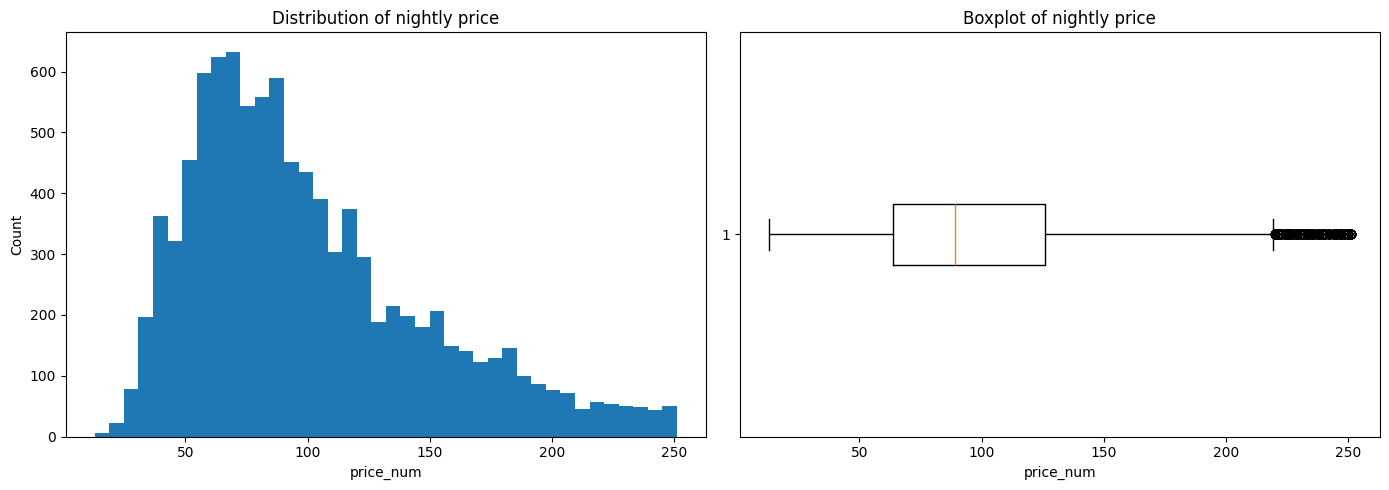

In [10]:
# ============================================================
# 6. Inspect the target distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["price_num"].dropna(), bins=40)
axes[0].set_title("Distribution of nightly price")
axes[0].set_xlabel("price_num")
axes[0].set_ylabel("Count")

axes[1].boxplot(df["price_num"].dropna(), vert=False)
axes[1].set_title("Boxplot of nightly price")
axes[1].set_xlabel("price_num")

plt.tight_layout()
plt.show()

## 7. Choose the input features

We use:
- **numeric features** that already have numeric meaning,
- **categorical features** that will later be one-hot encoded.

This feature set is based on the stronger version from the earlier regression notebook, but it is still taught in a step-by-step tutorial style.

In [11]:
# ============================================================
# 7. Feature lists
# ============================================================
numeric_features = [
    "latitude",
    "longitude",
    "accommodates",
    "bathrooms_num",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "host_response_rate_num",
    "host_acceptance_rate_num",
    "host_is_superhost_num",
    "host_identity_verified_num",
    "instant_bookable_num",
    "host_tenure_days",
    "days_since_last_review",
    "amenity_count",
    "calculated_host_listings_count",
    "review_scores_rating",
]

categorical_features = [
    "room_type",
    "property_type",
    "neighbourhood_joined",
    "host_response_time",
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['latitude', 'longitude', 'accommodates', 'bathrooms_num', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews', 'reviews_per_month', 'host_response_rate_num', 'host_acceptance_rate_num', 'host_is_superhost_num', 'host_identity_verified_num', 'instant_bookable_num', 'host_tenure_days', 'days_since_last_review', 'amenity_count', 'calculated_host_listings_count', 'review_scores_rating']

Categorical features:
['room_type', 'property_type', 'neighbourhood_joined', 'host_response_time']


## 8. Build `X` and `y`, then split the data

- `X` contains the input features
- `y` contains the target variable `price_num`

We keep part of the data aside as **test data** so we can evaluate the model on unseen examples.

In [12]:
# ============================================================
# 8. Create X and y, then split into train and test
# ============================================================
X = df[numeric_features + categorical_features].copy()
y = df["price_num"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train mean:", round(y_train.mean(), 2))
print("y_test mean :", round(y_test.mean(), 2))

X_train shape: (7196, 25)
X_test shape: (2399, 25)
y_train mean: 100.25
y_test mean : 100.04


## 9. Numeric preprocessing branch

For numeric columns we do two things:
1. **Impute missing values** with the median,
2. **Scale** the variables so they are on a similar range.

Scaling is particularly useful for linear models.

In [13]:
# ============================================================
# 9. Numeric preprocessing branch
# ============================================================
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

numeric_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

## 10. Categorical preprocessing branch

For categorical columns we do two things:
1. fill missing values with the most frequent category,
2. convert categories into binary columns using **one-hot encoding**.

We keep `handle_unknown="ignore"` so the model can still work if a new category appears in the test set.

In [14]:
# ============================================================
# 10. Categorical preprocessing branch
# ============================================================
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

categorical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])

## 11. Combine both branches into one preprocessor

A `ColumnTransformer` sends:
- numeric columns to the numeric branch,
- categorical columns to the categorical branch.

This is the cleanest way to keep all preprocessing in one place.

In [15]:
# ============================================================
# 11. Full preprocessor
# ============================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    sparse_threshold=1.0,
)

preprocessor

ColumnTransformer(sparse_threshold=1.0,
                  transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['latitude', 'longitude', 'accommodates',
                                  'bathrooms_num', 'bedrooms', 'beds',
                                  'minimum_nights', 'maximum_nights',
                                  'availability_365', 'number_of_reviews',
                                  'reviews_per_month', 'host_response_rate_num',
                                  'host_ac...
                                  'host_identity_verified_num',
                                  'instant_bookable_num', 'host_tenure_days',
                                  'days_since_last_review', 'amenity_count',
                                  'calculated_host_listings_count',
                                  'review_scores_rating']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['room_type', 'property_type',
                                  'neighbourhood_joined',
                                  'host_response_time'])])

## 12. Build one regression model step by step: Linear Regression

Now we create a full machine learning pipeline:
1. preprocess the data,
2. train a Linear Regression model.

In [16]:
# ============================================================
# 12. Linear Regression pipeline
# ============================================================
linear_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

linear_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(sparse_threshold=1.0,
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'accommodates',
                                                   'bathrooms_num', 'bedrooms',
                                                   'beds', 'minimum_nights',
                                                   'maximum_nights',
                                                   'availability_365',
                                                   'number_of_reviews',
                                                   'reviews_per_month',
                                                   '...
                                                   'host_tenure_days',
                                                   'days_since_last_review',
                                                   'amenity_count',
                                                   'calculated_host_listings_count',
                                                   'review_scores_rating']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['room_type', 'property_type',
                                                   'neighbourhood_joined',
                                                   'host_response_time'])])),
                ('regressor', LinearRegression())])

## 13. Train and evaluate the Linear Regression model

We fit the model on the training set, predict on the test set, and compute:
- **RMSE**: average prediction error in the original price unit,
- **R²**: how much variation in price is explained by the model.

In [17]:
# ============================================================
# 13. Train and evaluate Linear Regression
# ============================================================
linear_pipeline.fit(X_train, y_train)

y_pred_linear = linear_pipeline.predict(X_test)

linear_rmse = rmse(y_test, y_pred_linear)
linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression results")
print("-------------------------")
print(f"RMSE: {linear_rmse:.3f}")
print(f"R2  : {linear_r2:.3f}")

Linear Regression results
-------------------------
RMSE: 37.234
R2  : 0.408


## 14. Actual vs predicted plot

If predictions were perfect, all points would lie exactly on the diagonal dashed line.

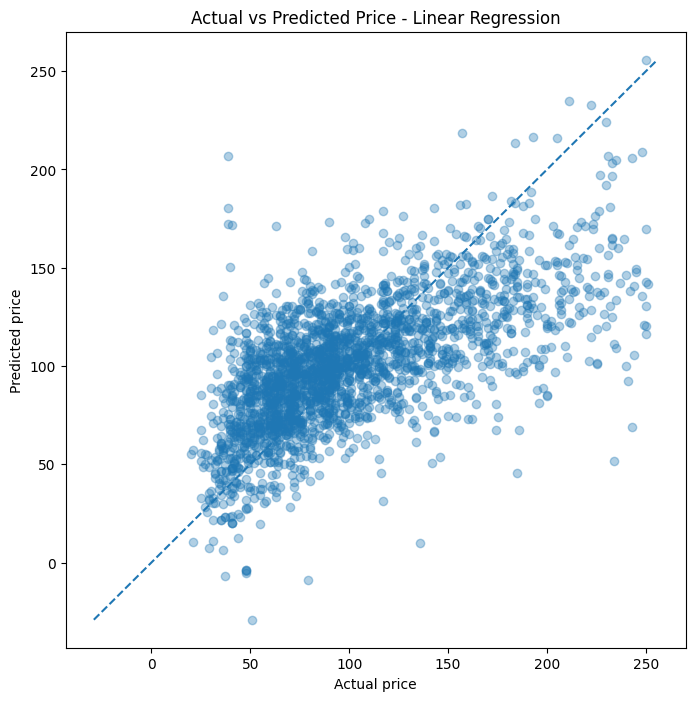

In [18]:
# ============================================================
# 14. Actual vs predicted plot
# ============================================================
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_linear, alpha=0.35)

min_val = min(y_test.min(), y_pred_linear.min())
max_val = max(y_test.max(), y_pred_linear.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title("Actual vs Predicted Price - Linear Regression")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.show()

## 15. Helper function for one regressor

Instead of rewriting the same code for every model, we wrap the repeated steps into a helper function.

This function:
1. creates a pipeline,
2. fits the model,
3. predicts on the test set,
4. computes metrics,
5. returns everything we need.

In [19]:
# ============================================================
# 15. Helper function for one regressor
# ============================================================
def train_and_evaluate_regressor(model_name, model_object, preprocessor, X_train, X_test, y_train, y_test):
    # Step 1: Build a pipeline with preprocessing first and regression second.
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", model_object),
        ]
    )

    # Step 2: Fit the full pipeline on the training data only.
    pipeline.fit(X_train, y_train)

    # Step 3: Use the fitted pipeline to predict prices for unseen test data.
    y_pred = pipeline.predict(X_test)

    # Step 4: Compute evaluation metrics.
    model_rmse = rmse(y_test, y_pred)
    model_r2 = r2_score(y_test, y_pred)

    # Step 5: Store the results in a simple dictionary.
    results_row = {
        "Model": model_name,
        "RMSE": model_rmse,
        "R2": model_r2,
    }

    # Step 6: Return the metrics row, the fitted pipeline, and predictions.
    return results_row, pipeline, y_pred

## 16. Compare multiple regression models

Now that we understand one model, we can scale the same workflow to several models.

In this tutorial we compare:
- Linear Regression
- Lasso Regression
- Decision Tree Regressor

In [20]:
# ============================================================
# 16. Compare multiple regression models
# ============================================================
regression_models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(alpha=0.001, max_iter=10000),
    "Decision Tree Regressor": DecisionTreeRegressor(
        random_state=RANDOM_STATE,
        max_depth=10,
        min_samples_leaf=8,
    ),
}

rows = []
fitted_pipelines = {}
predictions = {}

for model_name, model_object in regression_models.items():
    result_row, fitted_pipeline, y_pred = train_and_evaluate_regressor(
        model_name=model_name,
        model_object=model_object,
        preprocessor=preprocessor,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
    )

    rows.append(result_row)
    fitted_pipelines[model_name] = fitted_pipeline
    predictions[model_name] = y_pred

results_df = pd.DataFrame(rows).sort_values("RMSE", ascending=True).reset_index(drop=True)
results_df

,Model,RMSE,R2
0,Linear Regression,37.233530,0.408238
1,Lasso Regression,37.240977,0.408001
2,Decision Tree Regressor,38.022182,0.382904


## 17. Plot RMSE comparison

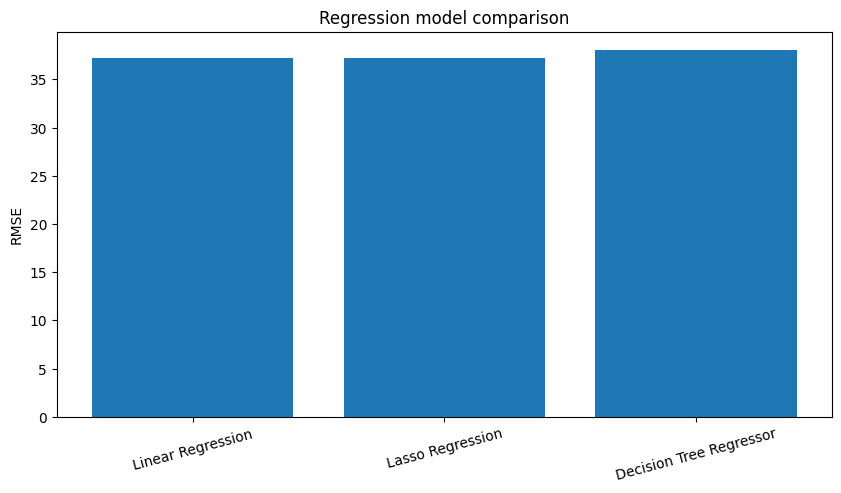

In [21]:
# ============================================================
# 17. Plot RMSE comparison
# ============================================================
plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Regression model comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.show()

## 18. Hyperparameter play: Lasso alpha

Students can change the value of `alpha` and see how the result changes.

In [22]:
# ============================================================
# 18A. Hyperparameter play: Lasso alpha
# ============================================================
lasso_rows = []

for alpha in [0.0001, 0.001, 0.01, 0.1]:
    result_row, _, _ = train_and_evaluate_regressor(
        model_name=f"Lasso (alpha={alpha})",
        model_object=Lasso(alpha=alpha, max_iter=10000),
        preprocessor=preprocessor,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
    )
    lasso_rows.append(result_row)

lasso_tuning_results = pd.DataFrame(lasso_rows).sort_values("RMSE", ascending=True).reset_index(drop=True)
lasso_tuning_results

,Model,RMSE,R2
0,Lasso (alpha=0.001),37.240977,0.408001
1,Lasso (alpha=0.0001),37.241076,0.407998
2,Lasso (alpha=0.01),37.263277,0.407292
3,Lasso (alpha=0.1),37.646362,0.395043


## 19. Hyperparameter play: Decision Tree depth

Students can also test how tree depth affects performance.

In [23]:
# ============================================================
# 18B. Hyperparameter play: Decision Tree max_depth
# ============================================================
tree_rows = []

for depth in [3, 5, 8, 10, None]:
    result_row, _, _ = train_and_evaluate_regressor(
        model_name=f"Decision Tree (max_depth={depth})",
        model_object=DecisionTreeRegressor(
            random_state=RANDOM_STATE,
            max_depth=depth,
            min_samples_leaf=8,
        ),
        preprocessor=preprocessor,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
    )
    tree_rows.append(result_row)

tree_tuning_results = pd.DataFrame(tree_rows).sort_values("RMSE", ascending=True).reset_index(drop=True)
tree_tuning_results

,Model,RMSE,R2
0,Decision Tree (max_depth=10),38.022182,0.382904
1,Decision Tree (max_depth=8),38.258768,0.375201
2,Decision Tree (max_depth=None),39.094391,0.347610
3,Decision Tree (max_depth=5),39.818610,0.323215
4,Decision Tree (max_depth=3),41.636947,0.259992


## 20. Takeaway

Main teaching message:
- first understand **one model** end to end,
- then generalize the same pattern to **multiple models**,
- keep preprocessing inside a pipeline,
- and compare models fairly using the same train/test split.